In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from torch.utils.data import DataLoader

os.chdir('../..')
sys.path.append('.')
import configs
from models import resnet18
from utils.dataset import load_cv_dataset
from utils.nn import set_seed
from utils.nn.io import load_embedding

device = torch.device('cuda:0')
set_seed(0)

In [2]:
# Step 1.1: Load a pretrained ResNet18 from PyTorch and modify the fc layer to directly output image embeddings.
embed = resnet18(**configs.resnet18_cifar100_params)
state = load_embedding('resnet18', 'cifar100', 'sl', '230429-1218')
embed.load_state_dict(state, strict=True)
num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
embed    = embed.to(device)

In [3]:
# Step 1.2: Load CIFAR10 training and test set with proper transforms.

trainset = load_cv_dataset('cifar10', train=True, augment=False)
testset  = load_cv_dataset('cifar10', train=False, augment=False)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
testloader  = DataLoader(testset, batch_size=128, shuffle=False, num_workers=0)
print('training transform:\n' + '\n'.join([f'==> {str(t)}' for t in trainset.transform.transforms]))
print('test transform:\n' + '\n'.join([f'==> {str(t)}' for t in testset.transform.transforms]))

training transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
test transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))


In [4]:
# Step 3: Embed CIFAR10 training data by the pretrained ResNet18.
embedding = []
labels = []

embed.eval()
with torch.no_grad():
    for images, targets in trainloader:
        images  = images.to(device)
        outputs = embed(images)
        embedding.extend(outputs.cpu().numpy())
        labels.extend(targets.numpy())

embedding = np.array(embedding)
labels = np.array(labels)

### Support Vector Machine

In [5]:
# Step 4.1: Grid search bst parameters for SVM.
params = dict(C=[1., 100., 1000.], gamma=['scale'])
search = GridSearchCV(SVC(kernel='rbf'), param_grid=params, cv=5, n_jobs=30)
search.fit(embedding, labels)
search.best_params_

{'C': 100.0, 'gamma': 'scale'}

In [6]:
# Step 4.2: Train SVMs with RBF kernel based on raw data.
svm_time      = time.time()
svm_embedding = SVC(kernel='rbf', decision_function_shape='ovr', **search.best_params_).fit(embedding, labels)
svm_time      = time.time() - svm_time

In [7]:
# Step 4.3: Train SVMs with RBF kernel based on dimension-reduced data.
components = list(range(10, 111, 20)) + list(range(150, 501, 50))
pca               = {}
pca_time          = {}
pca_svm_time      = {}
svm_embedding_pca = {}

for comp in components:
    pca_time[comp]     = time.time()
    pca[comp]          = PCA(n_components=comp)
    embedding_pca      = pca[comp].fit_transform(embedding)
    pca_time[comp]     = time.time() - pca_time[comp]
    pca_svm_time[comp] = time.time()
    svm_embedding_pca[comp] = SVC(kernel='rbf', decision_function_shape='ovr', **search.best_params_)
    svm_embedding_pca[comp].fit(embedding_pca, labels)
    pca_svm_time[comp] = time.time() - pca_svm_time[comp]

In [8]:
# Step 4.4: Compare the test performance of the two kinds of SVMs in step 4.

test_embedding = []
test_labels = []

with torch.no_grad():
    for images, targets in testloader:
        images  = images.to(device)
        outputs = embed(images)
        test_embedding.extend(outputs.cpu().numpy())
        test_labels.extend(targets.numpy())

test_embedding = np.array(test_embedding)
test_labels = np.array(test_labels)

test_pred_embedding = svm_embedding.predict(test_embedding)
svm_acc = accuracy_score(test_labels, test_pred_embedding)

svm_pca_acc = {}
for comp in components:
    test_embedding_pca = pca[comp].transform(test_embedding)
    test_pred_embedding_pca = svm_embedding_pca[comp].predict(test_embedding_pca)
    svm_pca_acc[comp] = accuracy_score(test_labels, test_pred_embedding_pca)

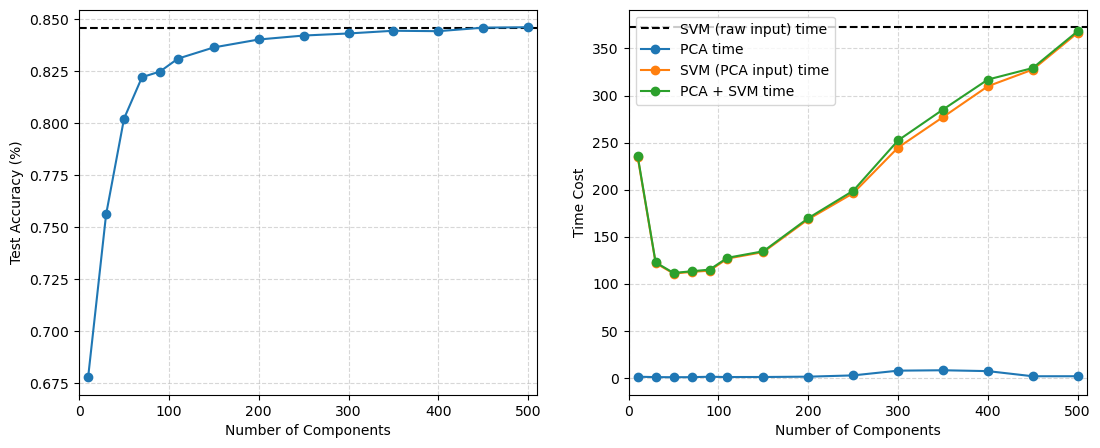

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].hlines(y=svm_acc, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='SVM acc')
ax[0].plot(components, list(svm_pca_acc.values()), '-o', label='PCA + SVM acc')
ax[0].set_xlabel('Number of Components')
ax[0].set_ylabel('Test Accuracy (%)')
ax[0].set_xlim([0, max(components) + 10])
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].hlines(y=svm_time, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='SVM (raw input) time')
ax[1].plot(components, list(pca_time.values()), '-o', label='PCA time')
ax[1].plot(components, list(pca_svm_time.values()), '-o', label='SVM (PCA input) time')
ax[1].plot(components, list(map(lambda a, b,: a+b, pca_time.values(), pca_svm_time.values())), '-o', label='PCA + SVM time')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Time Cost')
ax[1].set_xlim([0, max(components) + 10])
ax[1].legend(loc='best')
fig.show()

### Logistic Regression Classifier

In [10]:
# Step 5.1: Train Logistic Regression Classifier based on raw data.
lrc_time      = time.time()
lrc_embedding = LogisticRegression(max_iter=500, multi_class='ovr').fit(embedding, labels)
lrc_time      = time.time() - lrc_time

In [11]:
# Step 5.2: Train Logistic Regression Classifier based on dimension-reduced data.
components = list(range(10, 111, 20)) + list(range(150, 501, 50))
pca               = {}
pca_time          = {}
pca_lrc_time      = {}
lrc_embedding_pca = {}

for comp in components:
    pca_time[comp]     = time.time()
    pca[comp]          = PCA(n_components=comp)
    embedding_pca      = pca[comp].fit_transform(embedding)
    pca_time[comp]     = time.time() - pca_time[comp]
    pca_lrc_time[comp] = time.time()
    lrc_embedding_pca[comp] = LogisticRegression(max_iter=500, multi_class='ovr')
    lrc_embedding_pca[comp].fit(embedding_pca, labels)
    pca_lrc_time[comp] = time.time() - pca_lrc_time[comp]

In [12]:
# Step 5.3: Compare the test performance of the two kinds of Logistic Regression Classifiers in step 5.
test_embedding = []
test_labels = []

with torch.no_grad():
    for images, targets in testloader:
        images  = images.to(device)
        outputs = embed(images)
        test_embedding.extend(outputs.cpu().numpy())
        test_labels.extend(targets.numpy())

test_embedding = np.array(test_embedding)
test_labels = np.array(test_labels)

test_pred_embedding = lrc_embedding.predict(test_embedding)
lrc_acc = accuracy_score(test_labels, test_pred_embedding)

lrc_pca_acc = {}
for comp in components:
    test_embedding_pca = pca[comp].transform(test_embedding)
    test_pred_embedding_pca = lrc_embedding_pca[comp].predict(test_embedding_pca)
    lrc_pca_acc[comp] = accuracy_score(test_labels, test_pred_embedding_pca)

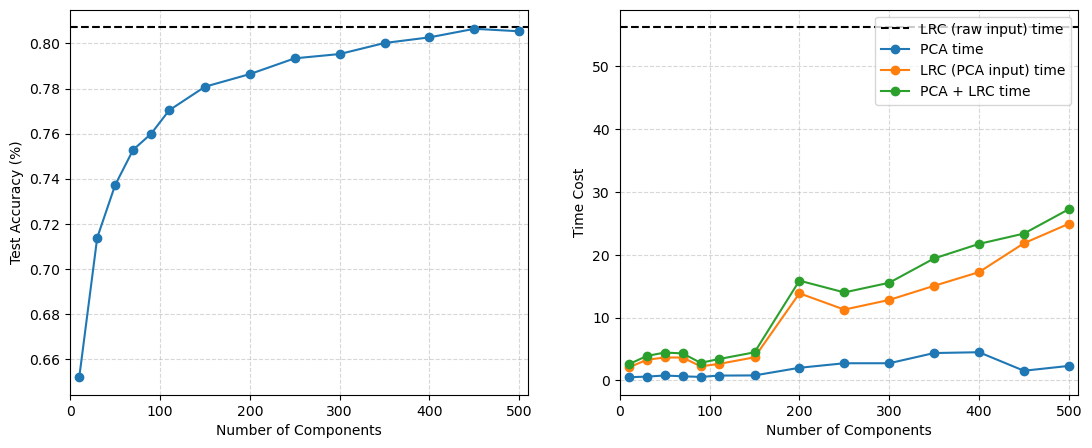

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].hlines(y=lrc_acc, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='LRC acc')
ax[0].plot(components, list(lrc_pca_acc.values()), '-o', label='PCA + LRC acc')
ax[0].set_xlabel('Number of Components')
ax[0].set_ylabel('Test Accuracy (%)')
ax[0].set_xlim([0, max(components) + 10])
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].hlines(y=lrc_time, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='LRC (raw input) time')
ax[1].plot(components, list(pca_time.values()), '-o', label='PCA time')
ax[1].plot(components, list(pca_lrc_time.values()), '-o', label='LRC (PCA input) time')
ax[1].plot(components, list(map(lambda a, b,: a+b, pca_time.values(), pca_lrc_time.values())), '-o', label='PCA + LRC time')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Time Cost')
ax[1].set_xlim([0, max(components) + 10])
ax[1].legend(loc='best')
fig.show()

### K-Nearset Neighbors

In [14]:
# Step 6.1: Grid search bst parameters for kNN.
params = dict(n_neighbors=[5, 7, 10, 15, 20])
search = GridSearchCV(KNeighborsClassifier(), param_grid=params, cv=10, n_jobs=10)
search.fit(embedding, labels)
search.best_params_

{'n_neighbors': 15}

In [15]:
# Step 6.2: Train kNN based on raw data.
knn_time      = time.time()
knn_embedding = KNeighborsClassifier(**search.best_params_).fit(embedding, labels)
knn_time      = time.time() - knn_time

In [16]:
# Step 6.3: Train kNN based on dimension-reduced data.
components = list(range(10, 111, 20)) + list(range(150, 501, 50))
pca               = {}
pca_time          = {}
pca_knn_time      = {}
knn_embedding_pca = {}

for comp in components:
    pca_time[comp]     = time.time()
    pca[comp]          = PCA(n_components=comp)
    embedding_pca      = pca[comp].fit_transform(embedding)
    pca_time[comp]     = time.time() - pca_time[comp]
    pca_knn_time[comp] = time.time()
    knn_embedding_pca[comp] = KNeighborsClassifier(**search.best_params_)
    knn_embedding_pca[comp].fit(embedding_pca, labels)
    pca_knn_time[comp] = time.time() - pca_knn_time[comp]

In [17]:
# Step 6.4: Compare the test performance of the two kinds of kNN in step 6.
test_embedding = []
test_labels = []

with torch.no_grad():
    for images, targets in testloader:
        images  = images.to(device)
        outputs = embed(images)
        test_embedding.extend(outputs.cpu().numpy())
        test_labels.extend(targets.numpy())

test_embedding = np.array(test_embedding)
test_labels = np.array(test_labels)

test_pred_embedding = knn_embedding.predict(test_embedding)
knn_acc = accuracy_score(test_labels, test_pred_embedding)

knn_pca_acc = {}
for comp in components:
    test_embedding_pca = pca[comp].transform(test_embedding)
    test_pred_embedding_pca = knn_embedding_pca[comp].predict(test_embedding_pca)
    knn_pca_acc[comp] = accuracy_score(test_labels, test_pred_embedding_pca)

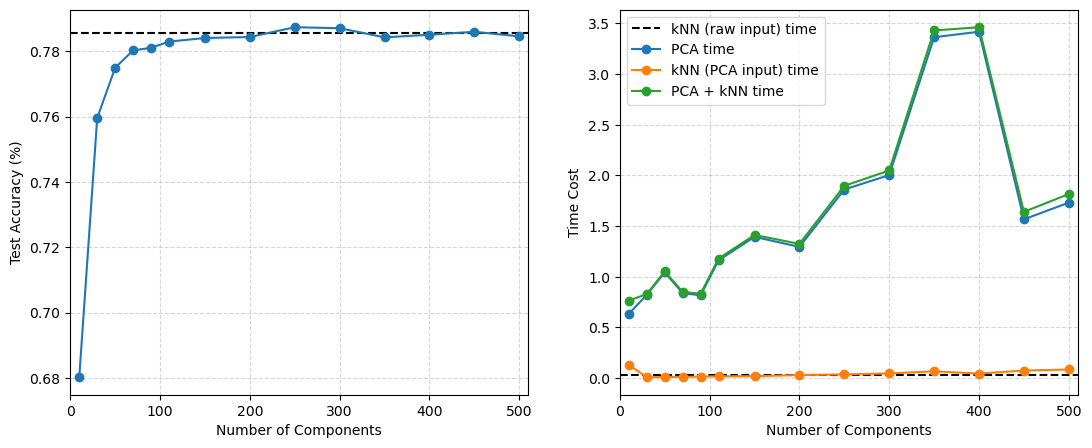

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].hlines(y=knn_acc, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='kNN acc')
ax[0].plot(components, list(knn_pca_acc.values()), '-o', label='PCA + kNN acc')
ax[0].set_xlabel('Number of Components')
ax[0].set_ylabel('Test Accuracy (%)')
ax[0].set_xlim([0, max(components) + 10])
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].hlines(y=knn_time, xmin=0, xmax=max(components) + 10, linestyles='--', colors='k', label='kNN (raw input) time')
ax[1].plot(components, list(pca_time.values()), '-o', label='PCA time')
ax[1].plot(components, list(pca_knn_time.values()), '-o', label='kNN (PCA input) time')
ax[1].plot(components, list(map(lambda a, b,: a+b, pca_time.values(), pca_knn_time.values())), '-o', label='PCA + kNN time')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Time Cost')
ax[1].set_xlim([0, max(components) + 10])
ax[1].legend(loc='best')
fig.show()